In [1]:
import pandas as pd
import numpy as np

# Load dataset
data = pd.read_csv("spambase.data", header=None)

# Features + labels
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y 
)

In [3]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def get_metrics(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Train Error": 1 - accuracy_score(y_train, y_train_pred),
        "Test Error": 1 - accuracy_score(y_test, y_test_pred),
        "Train F1": f1_score(y_train, y_train_pred),
        "Test F1": f1_score(y_test, y_test_pred),
        "Train AUC": roc_auc_score(y_train, y_train_prob),
        "Test AUC": roc_auc_score(y_test, y_test_prob),
    }

In [4]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_entropy.fit(X_train, y_train)

metrics_entropy = get_metrics(dt_entropy, X_train, y_train, X_test, y_test)

df_entropy = pd.DataFrame(metrics_entropy, index=["Entropy Tree"])
df_entropy

,Train Accuracy,Test Accuracy,Train Error,Test Error,Train F1,Test F1,Train AUC,Test AUC
Entropy Tree,0.99971,0.921807,0.00029,0.078193,0.999632,0.901532,1.0,0.919311


In [5]:
dt_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

dt_gini.fit(X_train, y_train)

metrics_gini = get_metrics(dt_gini, X_train, y_train, X_test, y_test)

df_gini = pd.DataFrame(metrics_gini, index=["Gini Tree"])
df_gini

,Train Accuracy,Test Accuracy,Train Error,Test Error,Train F1,Test F1,Train AUC,Test AUC
Gini Tree,0.99971,0.907906,0.00029,0.092094,0.999632,0.886266,1.0,0.908217


In [6]:
results_table = pd.concat([df_entropy, df_gini])
results_table

,Train Accuracy,Test Accuracy,Train Error,Test Error,Train F1,Test F1,Train AUC,Test AUC
Entropy Tree,0.99971,0.921807,0.00029,0.078193,0.999632,0.901532,1.0,0.919311
Gini Tree,0.99971,0.907906,0.00029,0.092094,0.999632,0.886266,1.0,0.908217


In [7]:
import matplotlib.pyplot as plt

depths = range(1, 21)

train_errors = []
test_errors = []

for d in depths:
    model = DecisionTreeClassifier(
        max_depth=d,
        criterion="entropy",
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_errors.append(1 - accuracy_score(y_train, train_pred))
    test_errors.append(1 - accuracy_score(y_test, test_pred))

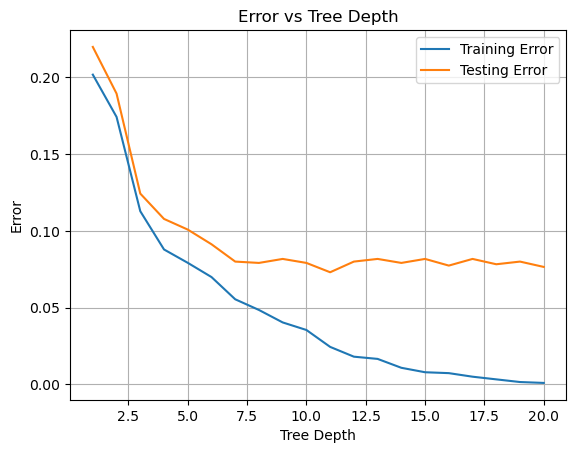

In [8]:
plt.figure()
plt.plot(depths, train_errors, label="Training Error")
plt.plot(depths, test_errors, label="Testing Error")

plt.xlabel("Tree Depth")
plt.ylabel("Error")
plt.title("Error vs Tree Depth")
plt.legend()
plt.grid()

plt.show()

In [8]:
best_depth = depths[np.argmin(test_errors)]
print("Best depth:", best_depth)

Best depth: 17
